# 1. 导入库与环境配置

本节目标：

- 搭建项目运行环境
- 导入所有将使用的核心库
- 检测 GPU / CPU 运行设备
- 为后续实验做可复现性配置

本项目以“数字图像处理”为核心，因此本节主要导入：

- **图像处理库**：OpenCV、scikit-image
- **数据处理库**：numpy、pandas
- **可视化库**：matplotlib、seaborn
- **深度学习库（后面 CNN 会用）**：PyTorch 或 TensorFlow（二选一，这里使用 PyTorch）
- **系统库**：os、glob、pathlib

重点：图像在计算机中以矩阵形式表达，因此 numpy + cv2 是本项目的最基本依赖。

下面开始正式导库与环境检测。


In [ ]:
# ================================================
# Section 1 -- 导入库与环境配置
# ================================================

# ----- 基础库 -----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
matplotlib.rcParams['axes.unicode_minus'] = False     # 解决负号显示问题

import os
import sys
import numpy as np
import pandas as pd

# ----- 图像处理库 -----
import cv2                                # OpenCV计算机视觉库
from skimage import io, color, filters, feature  # scikit-image图像处理库

# ----- 可视化库 -----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.2)  # 设置seaborn白色网格风格

# ----- 深度学习库（用于CNN） -----
import torch              # PyTorch深度学习框架
import torch.nn as nn     # 神经网络模块
import torch.nn.functional as F  # 函数式API

# ----- 实验可复现性 -----
import random

# 固定随机种子，保证每次运行结果一致
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# ================================================
# 检查 PyTorch 和 GPU 环境
# ================================================
print("PyTorch 版本:", torch.__version__)

if torch.cuda.is_available():
    device = torch.device("cuda")        # 使用GPU加速训练
    print("CUDA 可用")
    print("GPU 名称:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")         # 无GPU时使用CPU
    print("CUDA 不可用，使用 CPU")

print("当前计算设备:", device)

# ================================================
# 检查 OpenCV
# ================================================
print("OpenCV 版本:", cv2.__version__)

# 测试matplotlib图像输出：画一个空心圆验证环境
test_img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(test_img, (100, 100), 50, 255, 3)  # 圆心(100,100)，半径50，白色，线宽3

plt.imshow(test_img, cmap='gray')
plt.title("Matplotlib Test Image Output")
plt.axis("off")
plt.show()

### 2. 数据加载与初步探索（Notebook）
- **目的**：读入 CelebA 的 CSV 标注 + 部分图像，了解数据。
- **实现内容**：
  - 读取：
    - `list_attr_celeba.csv`（40 个属性）
    - `list_landmarks_celeba.csv`（5 个关键点）
    - `list_bbox_celeba.csv`（人脸框）
    - `list_eval_partition.csv`（train/val/test 划分）
  - 展示：
    - 数据量统计、属性分布条形图；
    - 随机几张脸 + 对应属性。
- **知识点**：图像数据集结构、标注文件组织方式。
- **主要库**：`pandas, cv2/PIL, matplotlib`。
---

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np

# 路径配置：适配当前目录结构（notebooks在dazuoye/notebooks，数据在dazuoye/data/archive）
DATA_ROOT = os.path.join("..", "data", "archive")   # 相对路径指向数据根目录
IMG_DIR   = os.path.join(DATA_ROOT, "img_align_celeba")  # 对齐后的人脸图像目录

# CelebA数据集的四个标注文件路径
ATTR_PATH = os.path.join(DATA_ROOT, "list_attr_celeba.csv")   # 40个人脸属性
BBOX_PATH = os.path.join(DATA_ROOT, "list_bbox_celeba.csv")   # 人脸边界框
LAND_PATH = os.path.join(DATA_ROOT, "list_landmarks_align_celeba.csv")  # 5个面部关键点
PART_PATH = os.path.join(DATA_ROOT, "list_eval_partition.csv")  # 训练/验证/测试划分

print("=== 路径确认 ===")
for p in [DATA_ROOT, IMG_DIR, ATTR_PATH, BBOX_PATH, LAND_PATH, PART_PATH]:
    print(f"{p:60s} -> {'OK' if os.path.exists(p) else 'NOT FOUND'}")

In [ ]:
# 读取CelebA数据集的四个CSV标注文件（逗号分隔）
attr_df = pd.read_csv(ATTR_PATH)   # 属性表：image_id + 40个二值属性（-1/1）
bbox_df = pd.read_csv(BBOX_PATH)   # 边界框：image_id, x_1, y_1, width, height
land_df = pd.read_csv(LAND_PATH)   # 关键点：image_id + 5个点的(x,y)坐标（10列）
part_df = pd.read_csv(PART_PATH)   # 划分表：image_id, partition（0=train,1=val,2=test）

print("属性表 shape:", attr_df.shape)
print("bbox   shape:", bbox_df.shape)
print("landm  shape:", land_df.shape)
print("划分表 shape:", part_df.shape)

display(attr_df.head())
display(bbox_df.head())
display(land_df.head())
display(part_df.head())

In [ ]:
# 查看各表的列名
print(attr_df.columns.tolist())
print(bbox_df.columns.tolist())
print(land_df.columns.tolist())
print(part_df.columns.tolist())

# 将partition列重命名为split，统一命名
part_df = part_df.rename(columns={"partition": "split"})

# 按image_id合并四个表，得到包含所有信息的总表
full_df = (
    attr_df
    .merge(bbox_df, on="image_id")    # 合并边界框信息
    .merge(land_df, on="image_id")    # 合并关键点信息
    .merge(part_df, on="image_id")    # 合并训练/验证/测试划分
)

print("合并后 shape:", full_df.shape)  # (202599, 56)：20万张图，56列信息
display(full_df.head())

In [43]:
print("数据集划分统计（0=train, 1=val, 2=test）：")
split_counts = full_df["split"].value_counts().sort_index()
print(split_counts)


数据集划分统计（0=train, 1=val, 2=test）：
split
0    162770
1     19867
2     19962
Name: count, dtype: int64


示例图片： ..\data\archive\img_align_celeba\154527.jpg


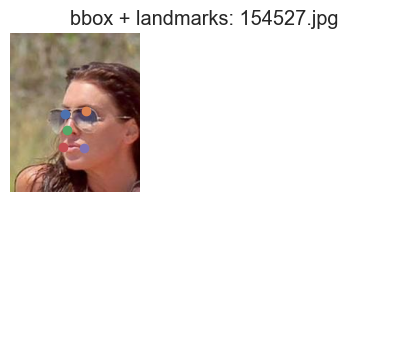

In [44]:

import os
import cv2
import matplotlib.pyplot as plt

# 这里用你真实的图片目录
IMG_DIR = IMG_DIR  # 如果上面有定义，就沿用；没有就写成 "img_align_celeba"

# 随机挑一张图
sample = full_df.sample(1, random_state=0).iloc[0]
img_path = os.path.join(IMG_DIR, sample["image_id"])
print("示例图片：", img_path)

# 读取图像
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)

# 画 bbox（列名按你现在的 CSV）
x, y, w, h = sample[["x_1", "y_1", "width", "height"]]
plt.gca().add_patch(
    plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
)

# 画五官关键点
for lx, ly in [
    ("lefteye_x", "lefteye_y"),
    ("righteye_x", "righteye_y"),
    ("nose_x", "nose_y"),
    ("leftmouth_x", "leftmouth_y"),
    ("rightmouth_x", "rightmouth_y"),
]:
    plt.scatter(sample[lx], sample[ly])

plt.axis("off")
plt.title(f"bbox + landmarks: {sample['image_id']}")
plt.show()


各属性正例比例：
Young          0.773617
Smiling        0.482080
Male           0.416754
Eyeglasses     0.065119
Wearing_Hat    0.048460
dtype: float64


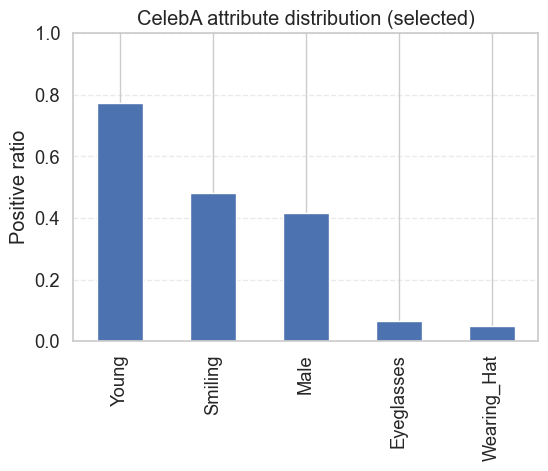

In [45]:
import matplotlib.pyplot as plt

# 随便挑一些有代表性的属性
attr_cols = ["Male", "Smiling", "Young", "Wearing_Hat", "Eyeglasses"]

# CelebA 属性是 -1/1，把它变成 0/1
attr_bin = full_df[attr_cols].replace({-1: 0, 1: 1})

pos_rates = attr_bin.mean().sort_values(ascending=False)
print("各属性正例比例：")
print(pos_rates)

plt.figure(figsize=(6, 4))
pos_rates.plot(kind="bar")
plt.ylabel("Positive ratio")
plt.title("CelebA attribute distribution (selected)")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


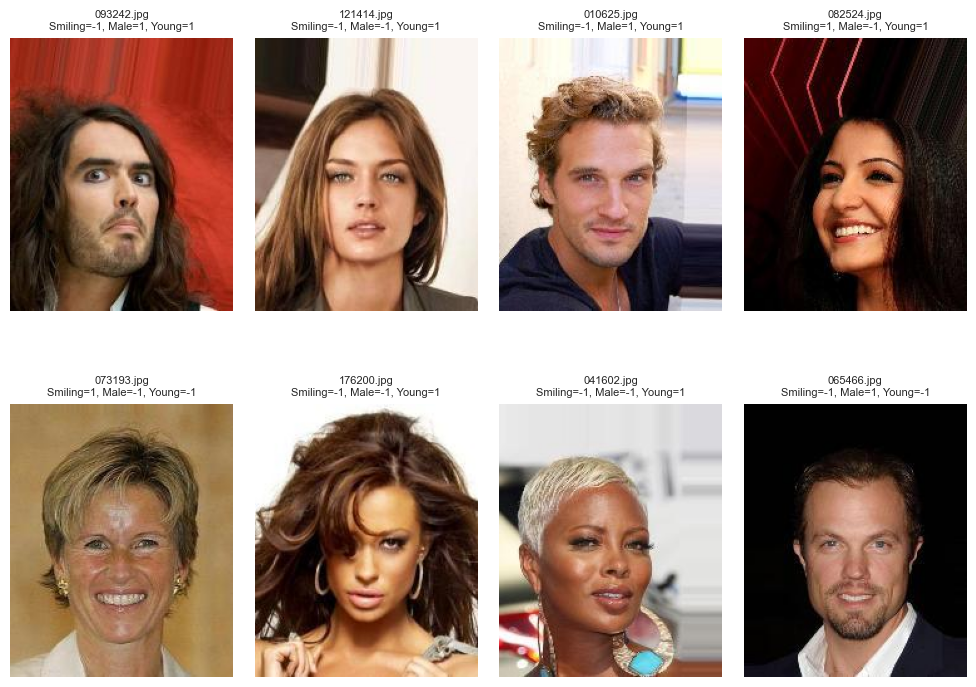

In [46]:
import cv2
from pathlib import Path

IMG_DIR = Path("../data/archive/img_align_celeba")  # 用你现在实际用的那个

samples = full_df.sample(8, random_state=42)
show_attrs = ["Smiling", "Male", "Young"]  # 展示在标题里

plt.figure(figsize=(10, 8))
for i, (_, row) in enumerate(samples.iterrows()):
    img_path = IMG_DIR / row["image_id"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

    title = row["image_id"] + "\n" + ", ".join(
        [f"{col}={row[col]}" for col in show_attrs]
    )
    plt.title(title, fontsize=8)

plt.tight_layout()
plt.show()



### 3. 图像几何变换与对齐（Notebook）

- **目的**：做人脸对齐/裁剪/缩放，兼顾数据增强。
- **实现内容**：
  - 根据 bbox 裁剪人脸区域。
  - 根据两眼关键点估算旋转，做仿射对齐（旋正）。
  - 统一缩放到固定尺寸（如 128×128 或 224×224）。
  - 做若干几何增强示例：旋转、水平翻转等。
- **知识点**：仿射变换、插值、数据增强对模型的作用。
- **主要库**：`cv2.getRotationMatrix2D, cv2.warpAffine, cv2.resize, cv2.flip`。
### 4. 图像滤波与去噪（Notebook）

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def load_image(row):
    """根据full_df的一行记录读取原始图像，返回BGR格式的numpy数组"""
    img_path = IMG_DIR / row["image_id"]
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"图像读取失败: {img_path}")
    return img


def show_rgb(img, title=None, ax=None):
    """安全显示BGR图像：自动处理空图像和坐标轴"""
    if ax is None:
        plt.figure(figsize=(4, 4))
        ax = plt.gca()
    if img is None or img.size == 0:
        ax.text(0.5, 0.5, "空图像", ha="center", va="center")
        ax.axis("off")
        if title:
            ax.set_title(title)
        return ax
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # BGR转RGB显示
    ax.axis("off")
    if title:
        ax.set_title(title)
    return ax


# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

In [ ]:
def compute_bbox_from_landmarks(row, img_shape, expand_ratio=0.3):
    """根据5个面部关键点计算人脸bbox，并按expand_ratio扩边"""
    h, w = img_shape[:2]

    # 提取5个关键点的x和y坐标
    xs = np.array([
        row["lefteye_x"], row["righteye_x"], row["nose_x"],
        row["leftmouth_x"], row["rightmouth_x"],
    ], dtype=np.float32)

    ys = np.array([
        row["lefteye_y"], row["righteye_y"], row["nose_y"],
        row["leftmouth_y"], row["rightmouth_y"],
    ], dtype=np.float32)

    # 计算关键点的包围盒中心和宽高
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    cx = (x_min + x_max) / 2  # 中心x
    cy = (y_min + y_max) / 2  # 中心y
    bw = (x_max - x_min) * (1 + expand_ratio)       # 扩展后的宽
    bh = (y_max - y_min) * (1 + expand_ratio * 1.2)  # 竖直方向多扩展20%

    # clip确保坐标不超出图像边界
    x1 = int(np.clip(cx - bw / 2, 0, w - 1))
    y1 = int(np.clip(cy - bh / 2, 0, h - 1))
    x2 = int(np.clip(cx + bw / 2, x1 + 1, w))
    y2 = int(np.clip(cy + bh / 2, y1 + 1, h))

    return x1, y1, x2, y2


def crop_face_auto(img, row, expand_ratio=0.3):
    """根据关键点自动计算bbox并裁剪人脸区域"""
    x1, y1, x2, y2 = compute_bbox_from_landmarks(row, img.shape, expand_ratio)
    face = img[y1:y2, x1:x2].copy()
    return face, (x1, y1, x2, y2)

In [ ]:
def align_face_by_eyes(img, row, output_size=(128, 128), expand_ratio=0.3):
    """人脸对齐：1.自动bbox裁剪 -> 2.双眼连线旋转对齐 -> 3.resize统一尺寸"""
    face, (x1, y1, x2, y2) = crop_face_auto(img, row, expand_ratio)
    fh, fw = face.shape[:2]

    # 将关键点坐标转换到裁剪后face的局部坐标系
    lx = row["lefteye_x"] - x1
    ly = row["lefteye_y"] - y1
    rx = row["righteye_x"] - x1
    ry = row["righteye_y"] - y1

    # 计算双眼连线的角度（arctan2返回弧度，再转为角度）
    dy = ry - ly
    dx = rx - lx
    angle = np.degrees(np.arctan2(dy, dx))
    center = ((lx + rx) / 2.0, (ly + ry) / 2.0)  # 双眼中点作为旋转中心

    # 旋转矩阵：将人脸旋正（使双眼连线水平）
    M = cv2.getRotationMatrix2D(center, -angle, 1.0)
    face_aligned = cv2.warpAffine(face, M, (fw, fh), flags=cv2.INTER_LINEAR)

    # 统一缩放到目标尺寸
    face_resized = cv2.resize(face_aligned, output_size, interpolation=cv2.INTER_LINEAR)
    return face_resized

In [ ]:
def augment_geometric(img, angle=15):
    """几何数据增强：小角度旋转 + 水平翻转，扩充训练集多样性"""
    h, w = img.shape[:2]
    center = (w / 2, h / 2)

    # 旋转增强：绕图像中心旋转angle度
    M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)
    img_rot = cv2.warpAffine(img, M_rot, (w, h), flags=cv2.INTER_LINEAR)

    img_flip = cv2.flip(img, 1)  # 水平翻转（flipCode=1）

    return img_rot, img_flip

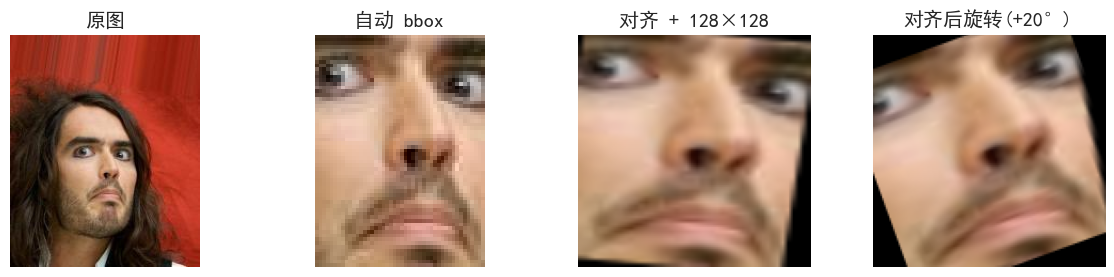

In [51]:

sample = full_df.sample(1, random_state=42).iloc[0]
img_raw = load_image(sample)
face_crop, _ = crop_face_auto(img_raw, sample, expand_ratio=0.3)
face_aligned = align_face_by_eyes(img_raw, sample, output_size=(128, 128))
rot_img, flip_img = augment_geometric(face_aligned, angle=20)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
show_rgb(img_raw, "原图", ax=axes[0])
show_rgb(face_crop, "自动 bbox", ax=axes[1])
show_rgb(face_aligned, "对齐 + 128×128", ax=axes[2])
show_rgb(rot_img, "对齐后旋转(+20°)", ax=axes[3])
plt.tight_layout()
plt.show()


- **目的**：演示空域滤波：降噪 + 锐化。
- **实现内容**：
  - 高斯滤波 / 均值滤波 / 中值滤波对比。
  - 拉普拉斯或自定义卷积核做锐化。
  - 展示“原图 vs 模糊 vs 锐化”对比。
- **知识点**：卷积、低通/高通滤波，噪声-细节的权衡。
- **主要库**：`cv2.GaussianBlur, cv2.medianBlur, cv2.filter2D`。

---

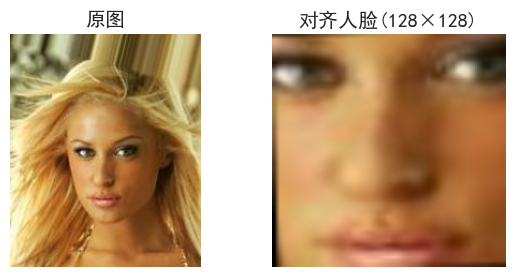

In [52]:

# 随机挑一张样本
sample = full_df.sample(1, random_state=123).iloc[0]

# 原图 + 对齐人脸
img_raw = load_image(sample)
face_aligned = align_face_by_eyes(img_raw, sample, output_size=(128, 128))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(img_raw, "原图", ax=axes[0])
show_rgb(face_aligned, "对齐人脸(128×128)", ax=axes[1])
plt.tight_layout()
plt.show()


In [ ]:
# 高斯滤波：平滑图像+保留一定结构，sigmaX控制高斯核的标准差
gauss = cv2.GaussianBlur(face_aligned, ksize=(5, 5), sigmaX=1.0)

# 均值滤波（box filter）：用邻域像素均值替代中心像素，模糊效果更强
mean = cv2.blur(face_aligned, ksize=(5, 5))

# 中值滤波：取邻域像素中值，对椒盐噪声去除效果好，同时保留边缘
median = cv2.medianBlur(face_aligned, ksize=5)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
show_rgb(face_aligned, "原图", ax=axes[0])
show_rgb(gauss, "高斯滤波", ax=axes[1])
show_rgb(mean, "均值滤波", ax=axes[2])
show_rgb(median, "中值滤波", ax=axes[3])
plt.tight_layout()
plt.show()

In [ ]:
# 锐化卷积核（拉普拉斯风格）：中心权重5，周围-1，增强图像细节
sharp_kernel = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]], dtype=np.float32)

sharp = cv2.filter2D(face_aligned, ddepth=-1, kernel=sharp_kernel)  # ddepth=-1保持原数据类型

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face_aligned, "原图", ax=axes[0])
show_rgb(sharp, "锐化(filter2D)", ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
# Unsharp Mask锐化：先做强高斯模糊，再用addWeighted做差分锐化
blur_strong = cv2.GaussianBlur(face_aligned, (0, 0), sigmaX=2.0)  # sigmaX=2.0的强模糊

# unsharp mask公式：result = 1.5*原图 - 0.5*模糊图，增强高频细节
unsharp = cv2.addWeighted(face_aligned, 1.5, blur_strong, -0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_rgb(face_aligned, "原图", ax=axes[0])
show_rgb(blur_strong, "强高斯模糊", ax=axes[1])
show_rgb(unsharp, "Unsharp mask 锐化", ax=axes[2])
plt.tight_layout()
plt.show()

- **目的**：演示空域滤波：降噪 + 锐化。
- **实现内容**：
  - 高斯滤波 / 均值滤波 / 中值滤波对比。
  - 拉普拉斯或自定义卷积核做锐化。
  - 展示“原图 vs 模糊 vs 锐化”对比。
- **知识点**：卷积、低通/高通滤波，噪声-细节的权衡。
- **主要库**：`cv2.GaussianBlur, cv2.medianBlur, cv2.filter2D`。

---
### 5. 直方图处理与图像增强（Notebook）
- **目的**：用直方图均衡化改善对比度，减轻光照差异。
- **实现内容**：
  - 灰度图直方图均衡化。
  - 彩色图：只对亮度通道做 HE 或 CLAHE。
  - 绘制均衡前后直方图和图像效果。
- **知识点**：灰度变换、CDF、全局 vs 自适应均衡。
- **主要库**：`cv2.equalizeHist, cv2.createCLAHE, skimage.exposure`。
---

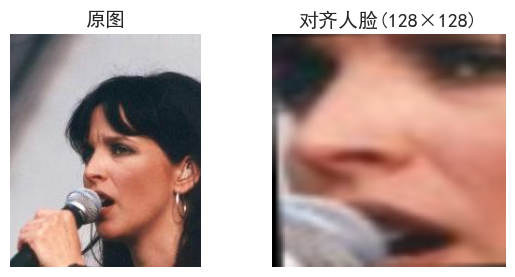

In [56]:

from skimage import exposure  # 后面可选用一下

sample = full_df.sample(1, random_state=2025).iloc[0]
img_raw = load_image(sample)
face = align_face_by_eyes(img_raw, sample, output_size=(128, 128))

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(img_raw, "原图", ax=ax[0])
show_rgb(face, "对齐人脸(128×128)", ax=ax[1])
plt.tight_layout()
plt.show()


In [ ]:
# 灰度图全局直方图均衡化（HE）：将像素值分布拉伸到均匀分布，增强对比度
face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)  # BGR转灰度
face_gray_he = cv2.equalizeHist(face_gray)  # 全局直方图均衡化

fig, axes = plt.subplots(2, 2, figsize=(8, 5))

axes[0, 0].imshow(face_gray, cmap="gray")
axes[0, 0].set_title("灰度原图")
axes[0, 0].axis("off")

axes[0, 1].imshow(face_gray_he, cmap="gray")
axes[0, 1].set_title("灰度均衡化")
axes[0, 1].axis("off")

axes[1, 0].hist(face_gray.ravel(), bins=256, range=(0, 256))  # ravel展平为一维统计
axes[1, 0].set_title("原图直方图")

axes[1, 1].hist(face_gray_he.ravel(), bins=256, range=(0, 256))
axes[1, 1].set_title("均衡化后直方图")

plt.tight_layout()
plt.show()

In [ ]:
# 彩色图像直方图均衡化：只对YCrCb色彩空间的Y（亮度）通道做HE，保持颜色不变
ycrcb = cv2.cvtColor(face, cv2.COLOR_BGR2YCrCb)  # BGR转YCrCb
Y, Cr, Cb = cv2.split(ycrcb)  # 分离三个通道

Y_he = cv2.equalizeHist(Y)  # 只对亮度Y通道做全局直方图均衡化

ycrcb_he = cv2.merge([Y_he, Cr, Cb])  # 重新合并三通道
face_color_he = cv2.cvtColor(ycrcb_he, cv2.COLOR_YCrCb2BGR)  # YCrCb转回BGR

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "原彩色图", ax=axes[0])
show_rgb(face_color_he, "亮度均衡后", ax=axes[1])
plt.tight_layout()
plt.show()

# 对比均衡化前后的Y通道直方图
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(Y.ravel(), bins=256, range=(0, 256))
axes[0].set_title("原 Y 通道直方图")
axes[1].hist(Y_he.ravel(), bins=256, range=(0, 256))
axes[1].set_title("HE 后 Y 通道直方图")
plt.tight_layout()
plt.show()

In [ ]:
# CLAHE（对比度受限自适应直方图均衡化）：比全局HE更精细，局部区域自适应
# clipLimit=2.0：对比度限制，防止过增强；tileGridSize=(8,8)：将图像分成8x8的块
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

Y_clahe = clahe.apply(Y)  # 对Y亮度通道做CLAHE

ycrcb_clahe = cv2.merge([Y_clahe, Cr, Cb])
face_color_clahe = cv2.cvtColor(ycrcb_clahe, cv2.COLOR_YCrCb2BGR)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_rgb(face, "原彩色", ax=axes[0])
show_rgb(face_color_he, "全局 HE", ax=axes[1])
show_rgb(face_color_clahe, "CLAHE", ax=axes[2])
plt.tight_layout()
plt.show()

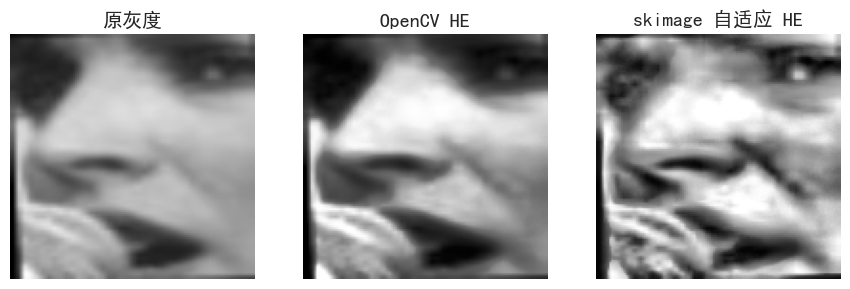

In [60]:

face_gray_float = face_gray / 255.0
face_gray_adapt = exposure.equalize_adapthist(face_gray_float, clip_limit=0.03)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(face_gray, cmap="gray")
axes[0].set_title("原灰度")
axes[0].axis("off")

axes[1].imshow(face_gray_he, cmap="gray")
axes[1].set_title("OpenCV HE")
axes[1].axis("off")

axes[2].imshow(face_gray_adapt, cmap="gray")
axes[2].set_title("skimage 自适应 HE")
axes[2].axis("off")

plt.tight_layout()
plt.show()


### 6. 图像分割与形态学处理（Notebook）
- **目的**：尝试把人脸前景从背景里分出来。
- **实现内容**：
  - Otsu 阈值法生成粗糙的人脸掩膜。
  - 形态学开/闭运算去噪和填洞。
  - 展示：“原图、初始掩膜、形态学后掩膜”。
  - 可选：对某几张图用 K-means 做简易颜色分割。
- **知识点**：阈值分割、腐蚀/膨胀、开闭运算。
- **主要库**：`cv2.threshold, cv2.morphologyEx, skimage.morphology`。
---

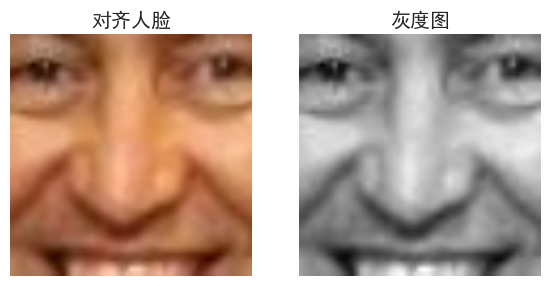

In [61]:

sample = full_df.sample(1, random_state=666).iloc[0]
img_raw = load_image(sample)
face = align_face_by_eyes(img_raw, sample, output_size=(128, 128))

face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "对齐人脸", ax=axes[0])
axes[1].imshow(face_gray, cmap="gray")
axes[1].set_title("灰度图")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Otsu自动阈值分割：自动计算最佳阈值，将灰度图二值化
# THRESH_BINARY + THRESH_OTSU：二值化+Otsu自动确定阈值
ret, mask_raw = cv2.threshold(
    face_gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu 自动阈值 =", ret)  # Otsu算法自动找到的阈值

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(face_gray, cmap="gray")
axes[0].set_title("灰度图")
axes[0].axis("off")

axes[1].imshow(mask_raw, cmap="gray")
axes[1].set_title("初始掩膜 (Otsu)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 形态学操作：对Otsu掩膜进行开运算去噪+闭运算填洞
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))  # 椭圆形结构元素3x3

# 开运算（MORPH_OPEN）：先腐蚀再膨胀，去除掩膜中的小白点噪声
mask_open = cv2.morphologyEx(mask_raw, cv2.MORPH_OPEN, kernel, iterations=1)

# 闭运算（MORPH_CLOSE）：先膨胀再腐蚀，填补掩膜中的小黑洞
mask_clean = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel, iterations=2)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(mask_raw, cmap="gray"); axes[0].set_title("初始掩膜"); axes[0].axis("off")
axes[1].imshow(mask_open, cmap="gray"); axes[1].set_title("开运算后"); axes[1].axis("off")
axes[2].imshow(mask_clean, cmap="gray"); axes[2].set_title("开+闭 后掩膜"); axes[2].axis("off")
plt.tight_layout()
plt.show()

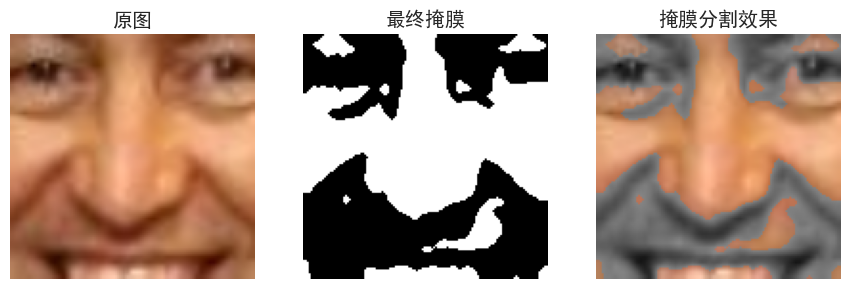

In [64]:

# 把 0/255 掩膜变成 0/1 的三通道
mask_3c = cv2.cvtColor(mask_clean, cv2.COLOR_GRAY2BGR) // 255

# 前景 = face * mask；背景用灰色填充方便对比
foreground = face * mask_3c
background_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
background_gray = cv2.cvtColor(background_gray, cv2.COLOR_GRAY2BGR)
bg_with_hole = background_gray * (1 - mask_3c)
segmented = foreground + bg_with_hole

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_rgb(face, "原图", ax=axes[0])
axes[1].imshow(mask_clean, cmap="gray")
axes[1].set_title("最终掩膜")
axes[1].axis("off")
show_rgb(segmented, "掩膜分割效果", ax=axes[2])
plt.tight_layout()
plt.show()


In [ ]:
# K-means颜色分割：将像素按颜色聚类为K类，实现简化/分割效果
Z = face.reshape((-1, 3)).astype(np.float32)  # 展平为(N,3)的float32数组

K = 3  # 聚类数：将颜色分为3类
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)  # 迭代终止条件
ret, labels, centers = cv2.kmeans(
    Z, K, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS  # attempts=5次随机初始化取最优
)

centers = np.uint8(centers)  # 将聚类中心转回uint8
seg_kmeans = centers[labels.flatten()].reshape(face.shape)  # 用聚类中心替换每个像素

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "原图", ax=axes[0])
show_rgb(seg_kmeans, "K-means 颜色分割 (K=3)", ax=axes[1])
plt.tight_layout()
plt.show()

- **目的**：提取轮廓结构（下巴、眼睛、眼镜框等）。
- **实现内容**：
  - 计算 Sobel X/Y、梯度幅值图。
  - Canny 边缘检测。
  - 将边缘叠加到原图上展示。
- **知识点**：一阶/二阶导、Sobel、Canny 各步骤。
- **主要库**：`cv2.Sobel, cv2.Canny, skimage.filters, skimage.feature.canny`。

---

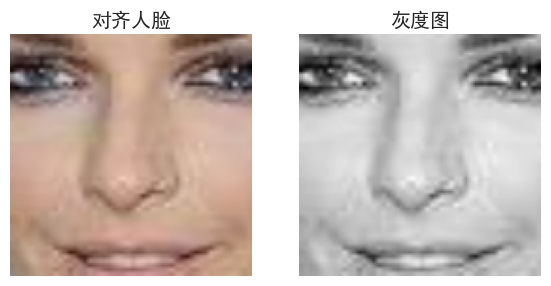

In [66]:

sample = full_df.sample(1, random_state=777).iloc[0]
img_raw = load_image(sample)
face = align_face_by_eyes(img_raw, sample, output_size=(128, 128))
face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "对齐人脸", ax=axes[0])
axes[1].imshow(face_gray, cmap="gray")
axes[1].set_title("灰度图")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Sobel边缘检测：计算x和y方向的一阶导数（梯度）
sobel_x = cv2.Sobel(face_gray, cv2.CV_64F, 1, 0, ksize=3)  # x方向梯度（垂直边缘）
sobel_y = cv2.Sobel(face_gray, cv2.CV_64F, 0, 1, ksize=3)  # y方向梯度（水平边缘）

# 梯度幅值 = sqrt(Gx^2 + Gy^2)，综合两个方向的边缘强度
grad_mag = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
grad_mag = np.uint8(255 * grad_mag / grad_mag.max())  # 归一化到0-255

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(np.abs(sobel_x), cmap="gray"); axes[0].set_title("Sobel X"); axes[0].axis("off")
axes[1].imshow(np.abs(sobel_y), cmap="gray"); axes[1].set_title("Sobel Y"); axes[1].axis("off")
axes[2].imshow(grad_mag, cmap="gray"); axes[2].set_title("梯度幅值"); axes[2].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Canny边缘检测：双阈值50和150，非极大值抑制+双阈值滞后跟踪
edges = cv2.Canny(face_gray, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(face_gray, cmap="gray"); axes[0].set_title("灰度图"); axes[0].axis("off")
axes[1].imshow(edges, cmap="gray"); axes[1].set_title("Canny 边缘"); axes[1].axis("off")
plt.tight_layout()
plt.show()

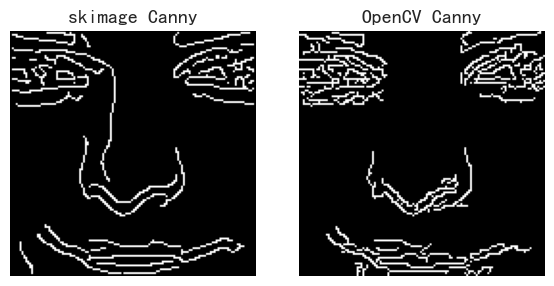

In [69]:

from skimage.feature import canny

edges_ski = canny(face_gray, sigma=1.5)  # skimage 返回 True/False

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(edges_ski, cmap="gray")
axes[0].set_title("skimage Canny");
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("OpenCV Canny");
axes[1].axis("off")

plt.tight_layout()
plt.show()


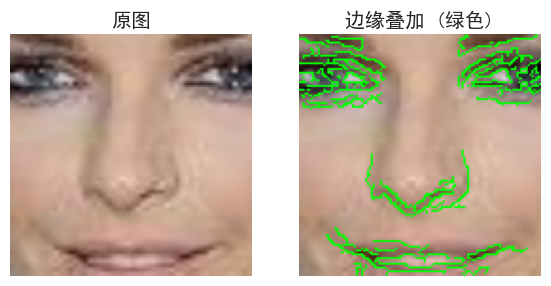

In [70]:

edges_color = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

overlay = face.copy()
overlay[edges > 0] = (0, 255, 0)  # 边缘画成绿色

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "原图", ax=axes[0])
show_rgb(overlay, "边缘叠加 (绿色)", ax=axes[1])
plt.tight_layout()
plt.show()



### 8. 特征提取（Notebook）
- **目的**：把图像变成特征向量，连接到“机器学习世界”。
- **实现内容**：
  - 基于分割掩膜的形状特征：面积、周长等。
  - 纹理特征：LBP / HOG。
  - 角点特征：Harris 角点或 ORB 关键点。
  - 可选：抽几张图用预训练 CNN 提取特征向量（当作对比）。
- **知识点**：形状特征、纹理特征、局部特征点的概念；图像→向量。
- **主要库**：
  - `skimage.feature.local_binary_pattern, skimage.feature.hog`
  - `- `cv2.cornerHarris, cv2.ORB_create` 等。

形状特征：
  面积 (pixels): 13074.0
  周长 (pixels): 770.0731538534164
  面积占比: 0.7979736328125


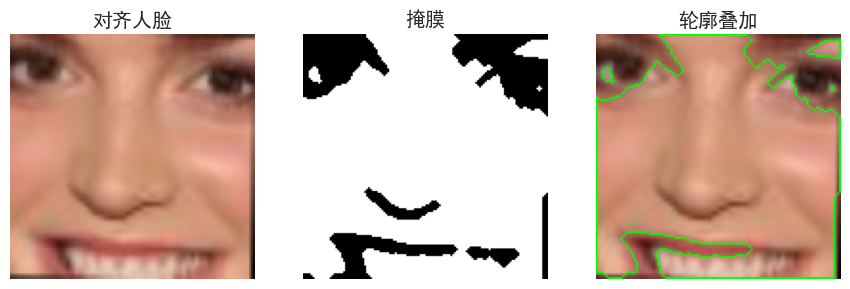

In [71]:

import cv2
import numpy as np
from skimage.feature import local_binary_pattern, hog


def get_face_and_mask(row, size=(128, 128)):
    """对齐人脸 + Otsu 分割 + 开闭运算，返回 face, mask_clean"""
    img_raw = load_image(row)
    face = align_face_by_eyes(img_raw, row, output_size=size)
    gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

    # Otsu 阈值
    _, mask = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask_open = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_clean = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel, iterations=2)
    return face, gray, mask_clean


sample = full_df.sample(1, random_state=8).iloc[0]
face, face_gray, mask_clean = get_face_and_mask(sample)

# 轮廓提取
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

area = 0.0
perimeter = 0.0
for cnt in contours:
    area += cv2.contourArea(cnt)
    perimeter += cv2.arcLength(cnt, True)

print("形状特征：")
print("  面积 (pixels):", area)
print("  周长 (pixels):", perimeter)
print("  面积占比:", area / (mask_clean.shape[0] * mask_clean.shape[1]))

# 可视化：原图 + 掩膜 + 轮廓
contour_vis = face.copy()
cv2.drawContours(contour_vis, contours, -1, (0, 255, 0), 1)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_rgb(face, "对齐人脸", ax=axes[0])
axes[1].imshow(mask_clean, cmap="gray");
axes[1].set_title("掩膜");
axes[1].axis("off")
show_rgb(contour_vis, "轮廓叠加", ax=axes[2])
plt.tight_layout()
plt.show()


In [ ]:
# LBP（Local Binary Pattern）局部二值模式：提取纹理特征
# P=8：周围8个采样点；R=1：采样半径；uniform模式减少特征维度
P = 8
R = 1
lbp = local_binary_pattern(face_gray, P, R, method="uniform")

# LBP直方图作为纹理特征向量（uniform模式下有P+2=10个bin）
n_bins = P + 2
hist_lbp, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

print("LBP 特征维度:", hist_lbp.shape)
print("LBP 特征前 10 维:", hist_lbp[:10])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(lbp, cmap="gray"); axes[0].set_title("LBP 图"); axes[0].axis("off")
axes[1].bar(np.arange(n_bins), hist_lbp); axes[1].set_title("LBP 直方图特征")
plt.tight_layout()
plt.show()

In [ ]:
# HOG（Histogram of Oriented Gradients）方向梯度直方图：形状特征描述子
# orientations=9：每个cell的梯度方向分9个bin
# pixels_per_cell=(8,8)：每个cell 8x8像素
# cells_per_block=(2,2)：每个block 2x2个cell，做L2-Hys归一化
hog_vec, hog_vis = hog(
    face_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,       # 返回可视化图像
    block_norm="L2-Hys"   # L2-Hys归一化
)

print("HOG 特征维度:", hog_vec.shape)  # 高维特征向量

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(face_gray, cmap="gray"); axes[0].set_title("灰度图"); axes[0].axis("off")
axes[1].imshow(hog_vis, cmap="gray"); axes[1].set_title("HOG 可视化"); axes[1].axis("off")
plt.tight_layout()
plt.show()

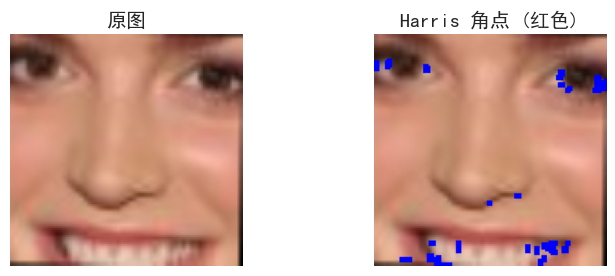

In [74]:

# Harris 角点检测
gray_float = np.float32(face_gray)
harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)
harris = cv2.dilate(harris, None)

# 阈值调高！去噪
th = 0.05  # 可以试 0.05~0.1
corner_vis = face.copy()
corner_vis[harris > th * harris.max()] = [255, 0, 0]
 # 角点涂成红色

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
show_rgb(face, "原图", ax=axes[0])
show_rgb(corner_vis, "Harris 角点 (红色)", ax=axes[1])
plt.tight_layout()
plt.show()


In [ ]:
# Harris角点检测：基于自相关矩阵特征值的角点响应函数
gray_float = np.float32(face_gray)  # Harris需要float32输入
harris = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)  # block=2邻域, Sobel核=3, k=0.04
harris = cv2.dilate(harris, None)  # 膨胀使角点更醒目

# 阈值筛选：响应值 > 1%最大值的点标记为角点
corner_vis = face.copy()
corner_vis[harris > 0.01 * harris.max()] = [0, 0, 255]  # BGR红色标记角点

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
show_rgb(face, "原图", ax=axes[0])
show_rgb(corner_vis, "Harris 角点 (红色)", ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
# 使用预训练ResNet18提取深度特征（迁移学习）
import torch
import torchvision.models as models
import torchvision.transforms as T

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)  # 加载ImageNet预训练权重
resnet18.eval()  # 设为评估模式（关闭Dropout和BatchNorm的训练行为）

# 去掉最后的全连接分类层，只保留卷积特征提取部分
feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-1])

# 图像预处理管道：转PIL -> 缩放224x224 -> 转Tensor -> ImageNet标准化
transform_cnn = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet均值
                std=[0.229, 0.224, 0.225]),     # ImageNet标准差
])

face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)  # BGR转RGB
inp = transform_cnn(face_rgb).unsqueeze(0)  # 添加batch维度 [1,3,224,224]

with torch.no_grad():  # 不计算梯度，节省内存
    feat = feature_extractor(inp)  # 输出 [1, 512, 1, 1]
feat_vec = feat.view(-1).cpu().numpy()  # 展平为512维特征向量

print("ResNet18 特征维度:", feat_vec.shape)  # (512,)
print("前 10 维:", feat_vec[:10])

### 9. 深度学习模型构建（Notebook）
- **目的**：做一个简单的人脸属性分类器（例如：性别 / 是否戴眼镜）。
- **实现内容**：
  - 从 `list_attr_celeba.csv` 中选 1–2 个属性作为标签。
  - 定义小型 CNN（或加载轻量级预训练模型并改最后一层）。
  - 打印模型结构（summary）。
- **知识点**：卷积层/池化层/全连接层的基本作用；模型尺寸与显存的关系。
- **主要库**：`torch` 或 `tensorflow.keras`。

In [ ]:
# 构建人脸属性分类的训练/验证数据集
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
import numpy as np

# 选择两个属性作为分类目标：性别(Male) + 是否戴眼镜(Eyeglasses)
target_attrs = ["Male", "Eyeglasses"]

# CelebA属性原始值为-1/1，映射为0/1（二分类标签）
attr_df_bin = full_df.copy()
for col in target_attrs:
    attr_df_bin[col] = attr_df_bin[col].replace({-1: 0, 1: 1})

# 按官方划分取子集：split=0训练集2万条，split=1验证集5千条
train_df = attr_df_bin[attr_df_bin["split"] == 0].sample(20000, random_state=0)
val_df = attr_df_bin[attr_df_bin["split"] == 1].sample(5000, random_state=0)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print(train_df[target_attrs].head())

In [ ]:
class CelebAFaceDataset(Dataset):
    """CelebA人脸属性数据集：自动加载图像、对齐人脸、返回(图像tensor, 标签tensor)"""
    
    def __init__(self, df, target_attrs, image_size=(128, 128)):
        self.df = df.reset_index(drop=True)
        self.target_attrs = target_attrs
        self.image_size = image_size

        # 图像预处理：ToTensor转[C,H,W]且归一化到[0,1]，再Normalize到[-1,1]
        self.transform = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_raw = load_image(row)      # BGR格式
        face = align_face_by_eyes(img_raw, row, output_size=self.image_size)  # 人脸对齐

        face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)  # BGR转RGB
        img_pil = Image.fromarray(face_rgb)               # numpy转PIL
        x = self.transform(img_pil)    # [3,H,W] tensor

        y_vals = row[self.target_attrs].values.astype(np.float32)
        y = torch.from_numpy(y_vals)  # 标签转float tensor，shape=[num_attrs]
        return x, y


train_dataset = CelebAFaceDataset(train_df, target_attrs, image_size=(128, 128))
val_dataset = CelebAFaceDataset(val_df, target_attrs, image_size=(128, 128))

# DataLoader：batch_size=64，训练集打乱顺序，使用2个worker进程加载
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

len(train_dataset), len(val_dataset)

In [ ]:
class SimpleCNN(nn.Module):
    """简单CNN用于多标签二分类：4层卷积+BatchNorm+MaxPool + 2层全连接"""
    
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # 3x128x128 -> 32x64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 3通道输入，32个3x3卷积核
            nn.BatchNorm2d(32),                            # 批归一化加速训练
            nn.ReLU(inplace=True),                         # ReLU激活函数
            nn.MaxPool2d(2),                               # 2x2最大池化，尺寸减半

            # 32x64x64 -> 64x32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 64x32x32 -> 128x16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 128x16x16 -> 256x8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # 展平：256*8*8 = 16384维
            nn.Linear(256 * 8 * 8, 512),    # 全连接层1
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),                # Dropout防过拟合
            nn.Linear(512, num_classes),    # 输出层：维度=属性个数（2）
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x  # 不做sigmoid，配合BCEWithLogitsLoss使用


num_classes = len(target_attrs)
model = SimpleCNN(num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # 将模型移到GPU或CPU

print(model)

def count_trainable_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("可训练参数量:", count_trainable_params(model))  # 约878万参数

In [ ]:
# 损失函数和优化器
criterion = nn.BCEWithLogitsLoss()  # 多标签二分类损失（内置sigmoid + BCE）
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Adam优化器，学习率0.001

In [ ]:
def sigmoid(x):
    """手动实现sigmoid函数，用于将logit转为概率"""
    return 1 / (1 + torch.exp(-x))


def evaluate(model, loader, device):
    """在验证集上评估模型：返回平均loss和每个属性的准确率"""
    model.eval()
    total_loss = 0.0
    total_samples = 0
    correct_per_attr = torch.zeros(num_classes, device=device)

    with torch.no_grad():  # 评估时不计算梯度
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            total_samples += xb.size(0)

            probs = sigmoid(logits)
            preds = (probs > 0.5).float()  # 概率>0.5判定为正类
            correct_per_attr += (preds == yb).sum(dim=0)

    avg_loss = total_loss / total_samples
    acc_per_attr = (correct_per_attr / total_samples).cpu().numpy()
    return avg_loss, acc_per_attr


# 训练循环：5个epoch
epochs = 5

for epoch in range(1, epochs + 1):
    model.train()  # 切换到训练模式（启用Dropout和BatchNorm的训练行为）
    running_loss = 0.0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()  # 清空上一步的梯度
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()        # 反向传播计算梯度
        optimizer.step()       # 更新模型参数

        running_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    train_loss = running_loss / total
    val_loss, val_acc_attr = evaluate(model, val_loader, device)

    acc_str = ", ".join(
        [f"{name}={acc:.3f}" for name, acc in zip(target_attrs, val_acc_attr)]
    )
    print(f"[Epoch {epoch}/{epochs}] "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  |  {acc_str}")